In [ ]:
import marimo as mo
import numpy as np
from sklearn.neighbors import (
    KNeighborsClassifier,
)  # non serve importare tutto sklearn
from sklearn.model_selection import train_test_split
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

sns.set_theme()

# Algoritmo k-NN e prima applicazione di sklearn

Il **k-NN** (*k-nearest neighbors*) è un semplice algoritmo *supervisionato*. L'idea di fondo è, in maniera concettualmente simile al k-means clustering, di considerare $k$ punti "vicini" ad un certo dato ed assegnare al dato selezionato la classe più popolare in quel gruppo.
***

## Passaggi preliminari

Come prima cosa vanno importati i dati su cui operare: successivamente li facciamo partizionare (con una funzione dedicata di `sklearn`) in un *test dataset* (quello che "contiene le risposte giuste") e un *training dataset* (quello che l'algoritmo usa per "imparare").

Il dataset di esempio qui (e spesso trovato come esempio) è quello di un insieme di 150 immagini del fiore iris, ***bilanciato*** nelle 3 classi *versicolor, virginica e setosa*. Le feature utilizzate sono:
- lunghezza e larghezza del petalo
- lunghezza e larghezza del sepalo
> L'implicazione del bilanciamento delle classi è che nelle metriche di interesse sulla performance dell'algoritmo non abbiamo bisogno di usare la loro versione "percentuale".

In [ ]:
df = sns.load_dataset("iris")

df.head()

<marimo-table data-initial-value='[]' data-label='null' data-data='"[{\"sepal_length\":5.1,\"sepal_width\":3.5,\"petal_length\":1.4,\"petal_width\":0.2,\"species\":\"setosa\"},{\"sepal_length\":4.9,\"sepal_width\":3.0,\"petal_length\":1.4,\"petal_width\":0.2,\"species\":\"setosa\"},{\"sepal_length\":4.7,\"sepal_width\":3.2,\"petal_length\":1.3,\"petal_width\":0.2,\"species\":\"setosa\"},{\"sepal_length\":4.6,\"sepal_width\":3.1,\"petal_length\":1.5,\"petal_width\":0.2,\"species\":\"setosa\"},{\"sepal_length\":5.0,\"sepal_width\":3.6,\"petal_length\":1.4,\"petal_width\":0.2,\"species\":\"setosa\"}]"' data-total-rows='5' data-total-columns='5' data-max-columns='50' data-banner-text='""' data-pagination='true' data-page-size='10' data-field-types='[["sepal_length",["number","float64"]],["sepal_width",["number","float64"]],["petal_length",["number","float64"]],["petal_width",["number","float64"]],["species",["string","object"]]]' data-show-filters='true' data-show-download='true' data-show-column-summaries='false' data-show-data-types='true' data-show-page-size-selector='false' data-show-column-explorer='true' data-show-chart-builder='true' data-row-headers='[]' data-has-stable-row-id='false' data-lazy='false' data-preload='false' data-download-file-name='"df"'>

Puramente a scopo analitico, osserviamo il *pair plot* delle 4 feature. Le tipologie di iris sono classificate da `species`, per cui si specifica che la separazione dei colori è rispetto a quel parametro:

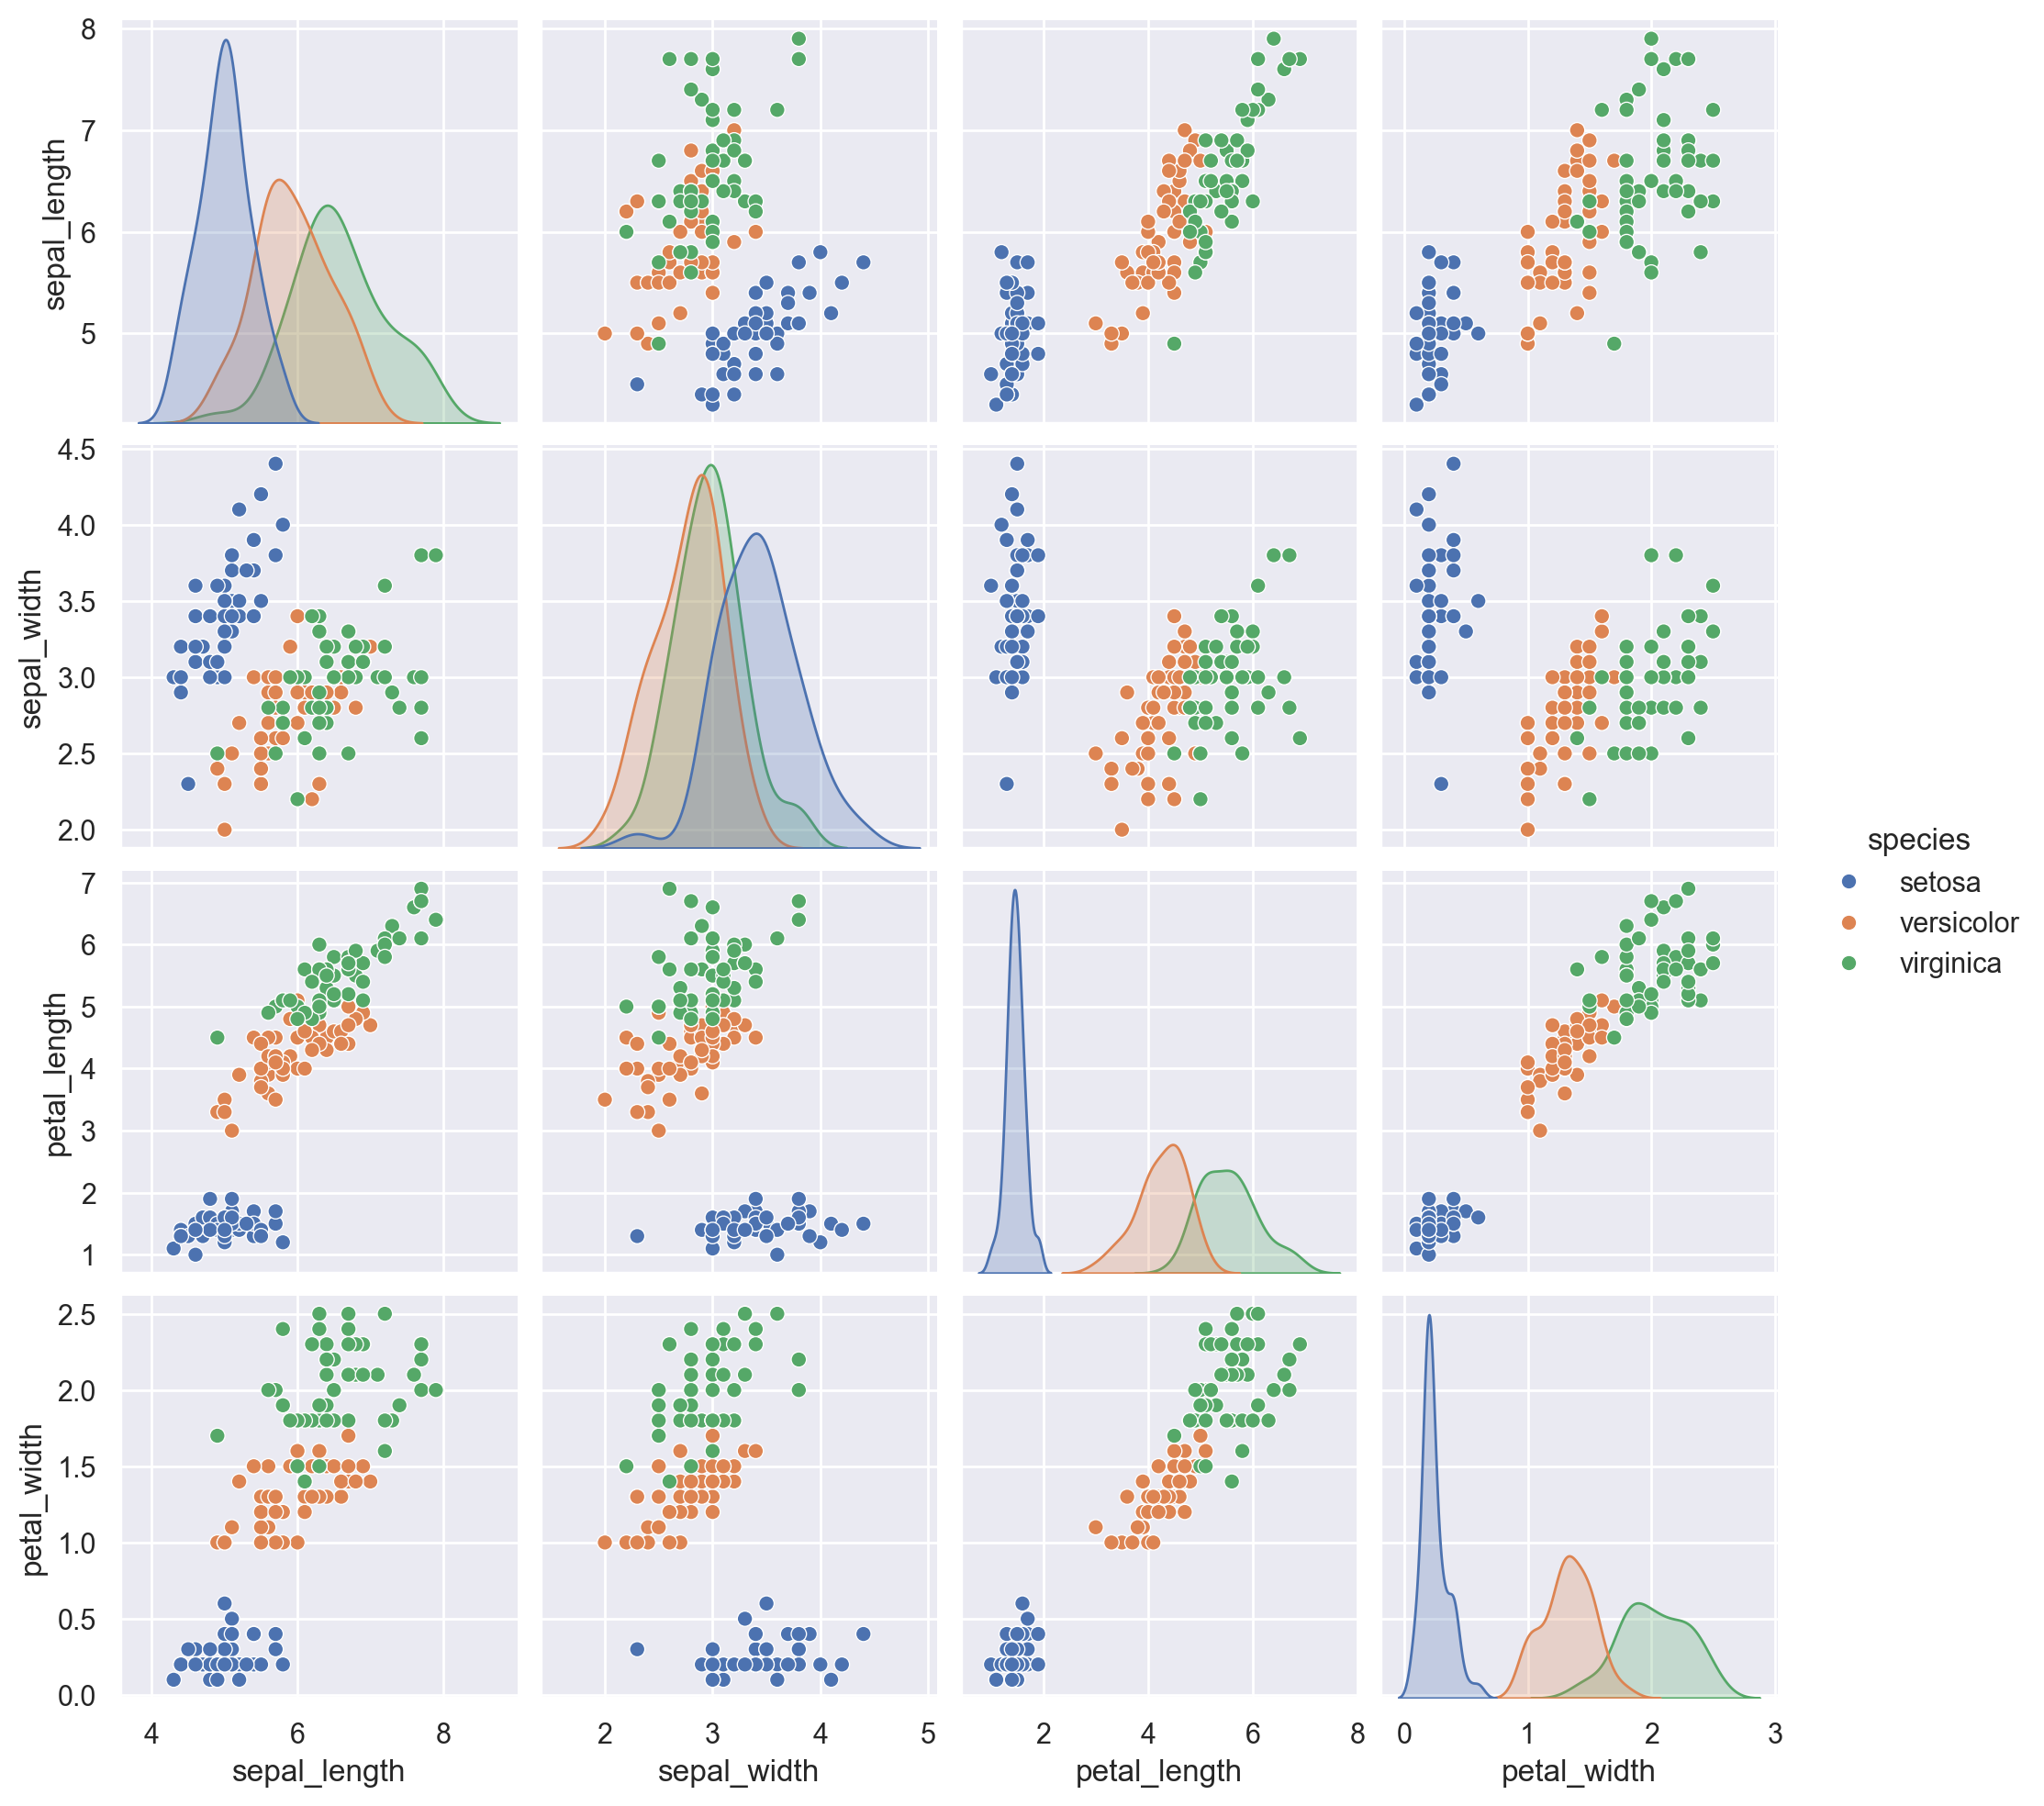

In [ ]:
sns.pairplot(data=df, hue="species")

**Gli elementi in diagonale mostrano solo le distribuzioni rispetto a quella feature**.

Immediatamente si nota che molte delle feature sono discriminanti, con l'eccezione della copia `sepal_length, sepal_width` dove vi è una sovrapposizione più notevole.

Per questioni sia di funzionamento del metodo che di memoria siamo soliti appiattire il dataset: invece di avere $n$ vettori con $k$ feature (per una matrice di dimensione $n \times k$) passiamo una lista di liste (che all'atto pratico è un array unidimensionale di $n$ elementi lunghi $k$).

In [ ]:
x = df.iloc[
    :, 0:4
]  # questo prende il set di dati considerando solo le feature

y = df["species"].values.ravel()
# questo prende il set di dati *sulla sola caratteristica sulla quale vogliamo che il modello faccia la previsione*, in questo caso a partire dalle dimensioni di petali e sepali deve predire la specie

# print(dataset)

Separo il dataset: `train_test_split` è definita tale da prendere gli array forniti (quanti essi siano, qui 2) e suddividere ciascuno di essi in insieme di training e insieme test, per cui a destra, avendogli passato x ed y, restituisce la suddivisione di x e la suddivisione di y.
- `random_state` è semplicemente il seed che la funzione utilizza quando raggruppa i dati nei set di training e test. Qui è assegnato un valore fisso, ma nulla toglie (ed è anzi forse meglio) passare un `rand` per controllare che il modello sia performante in generale
- `stratify` è necessario per mantenere le propozioni: vogliamo che le 3 specie di iris continuino ad essere equipartite in ciascun set

In [ ]:
x_train, x_test, y_train, y_test = train_test_split(
    x, y, test_size=0.2, random_state=10, stratify=y
)

Vanno ora standardizzate le feature: a puro scopo d'esempio (nota per il futuro: serve spiegare gli scaler e gli altri metodi di ribilanciamento dei valori delle feature) utilizzo lo *standard scaler*